# Community Detection — Visualization

**Project:** Community Detection in Social Networks  
**Authors:** Ahmet Doğaç Altın & Mükremin Berkay Can

## What this notebook does

This notebook visualizes the results from `02_community_detection.ipynb`:

1. **Plan A summary** — modularity, runtime, stability comparison (Louvain vs Leiden)
2. **Community size distribution** — ranked bar chart + log-log CDF
3. **Inter-community connectivity heatmap** — edge density between the top communities
4. **Plan B ego-network validation** — NMI/ARI distributions + scatter plots
5. **Network layout sample** — spring-layout visualization of a medium-sized ego network colored by detected community

In [1]:
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import igraph as ig
import leidenalg as la

DATA_DIR = Path("./data")
EGO_DIR  = DATA_DIR / "twitter"
GCC_PICKLE = DATA_DIR / "twitter_gcc.pickle"

# Load saved results from notebook 02
plana_df = pd.read_csv("plana_per_seed_results.csv")
planb_df = pd.read_csv("planb_per_ego_results.csv")

# Load GCC
gcc = ig.Graph.Read_Pickle(str(GCC_PICKLE))
print(f"Loaded GCC: |V| = {gcc.vcount():,}   |E| = {gcc.ecount():,}")
print(f"Plan A seeds: {len(plana_df)} rows")
print(f"Plan B egos:  {len(planb_df)} egos evaluated")

Loaded GCC: |V| = 81,306   |E| = 1,342,296
Plan A seeds: 20 rows
Plan B egos:  340 egos evaluated


## 1. Plan A — Algorithm comparison overview

Side-by-side boxplots for modularity, number of communities, and runtime across 10 seeds.

C:\Users\suuser\AppData\Local\Temp\ipykernel_15944\1235823663.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\suuser\AppData\Local\Temp\ipykernel_15944\1235823663.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\suuser\AppData\Local\Temp\ipykernel_15944\1235823663.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


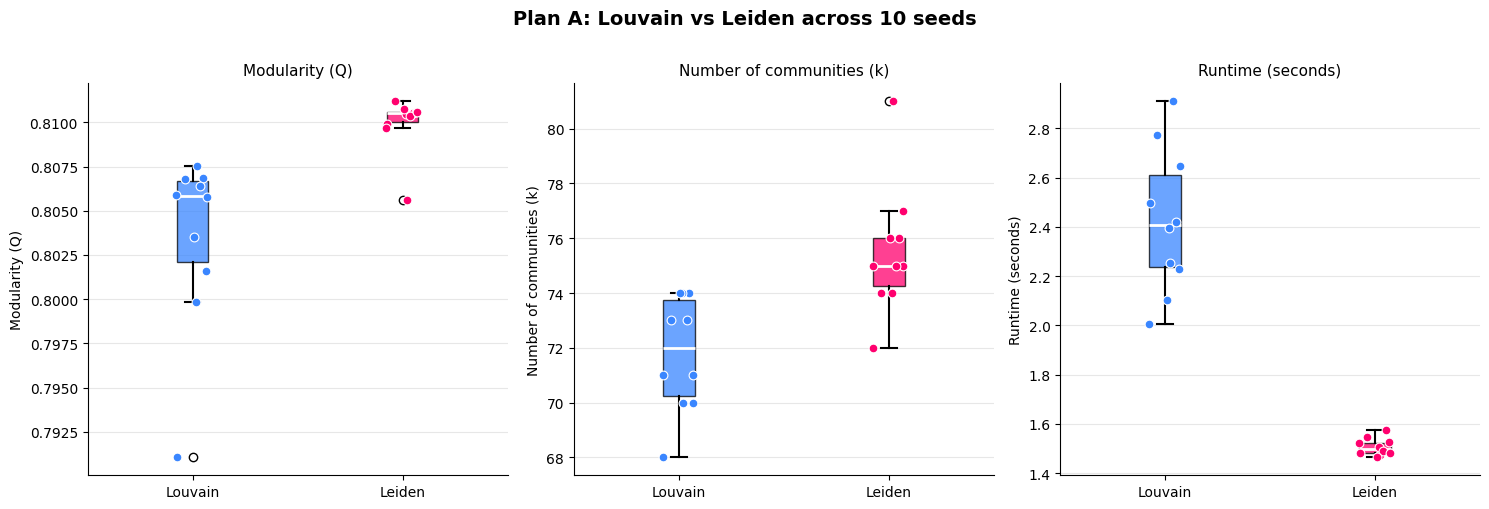

Saved: viz_plana_boxplots.png


In [2]:
COLORS = {"Louvain": "#3a86ff", "Leiden": "#ff006e"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Plan A: Louvain vs Leiden across 10 seeds", fontsize=14, fontweight="bold", y=1.01)

metrics = [
    ("modularity",    "Modularity (Q)"),
    ("n_communities", "Number of communities (k)"),
    ("runtime_s",     "Runtime (seconds)"),
]

for ax, (col, label) in zip(axes, metrics):
    data_lou = plana_df[plana_df["algo"] == "Louvain"][col].values
    data_lei = plana_df[plana_df["algo"] == "Leiden"][col].values

    bp = ax.boxplot(
        [data_lou, data_lei],
        labels=["Louvain", "Leiden"],
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
    )
    for patch, algo in zip(bp["boxes"], ["Louvain", "Leiden"]):
        patch.set_facecolor(COLORS[algo])
        patch.set_alpha(0.75)

    # Overlay individual points
    for i, (data, algo) in enumerate([(data_lou, "Louvain"), (data_lei, "Leiden")], 1):
        jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(data))
        ax.scatter(i + jitter, data, color=COLORS[algo], edgecolors="white",
                   linewidths=0.8, zorder=5, s=40)

    ax.set_ylabel(label)
    ax.set_title(label, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_plana_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_plana_boxplots.png")

## 2. Community size distribution

We pick the best-modularity run from each algorithm and compare how communities are sized.

In [3]:
# Re-run best partition from each algorithm to get size data
# (we use a fixed seed for reproducibility)
best_lou_seed = plana_df[plana_df["algo"] == "Louvain"].sort_values("modularity", ascending=False).iloc[0]["seed"]
best_lei_seed = plana_df[plana_df["algo"] == "Leiden"].sort_values("modularity", ascending=False).iloc[0]["seed"]
print(f"Best Louvain seed: {int(best_lou_seed)}, Best Leiden seed: {int(best_lei_seed)}")

part_lou = gcc.community_multilevel()
part_lei = la.find_partition(gcc, la.ModularityVertexPartition, seed=int(best_lei_seed))

lou_sizes = sorted([len(c) for c in part_lou], reverse=True)
lei_sizes = sorted([len(c) for c in part_lei], reverse=True)

print(f"Louvain: {len(lou_sizes)} communities, largest={lou_sizes[0]:,}, median={np.median(lou_sizes):.0f}")
print(f"Leiden:  {len(lei_sizes)} communities, largest={lei_sizes[0]:,}, median={np.median(lei_sizes):.0f}")

Best Louvain seed: 42, Best Leiden seed: 43
Louvain: 70 communities, largest=10,062, median=418
Leiden:  74 communities, largest=9,353, median=420


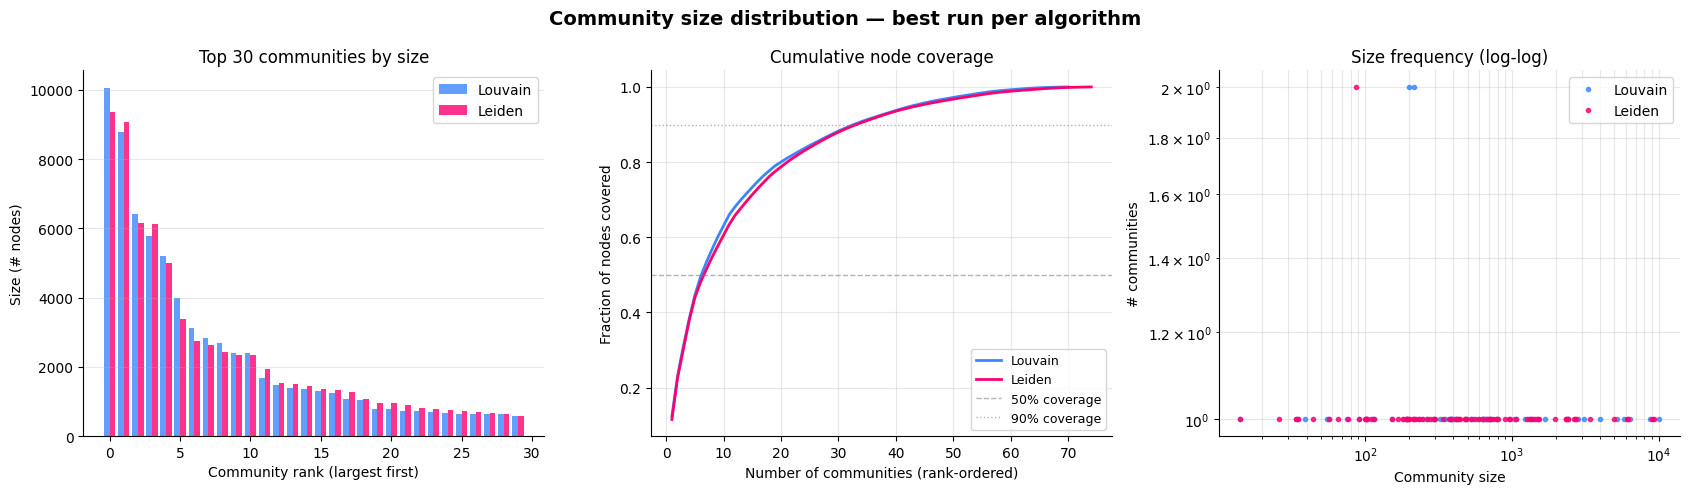

Saved: viz_community_sizes.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Community size distribution — best run per algorithm", fontsize=14, fontweight="bold")

# --- 2a: top 30 bar chart ---
ax = axes[0]
top_n = 30
x = np.arange(top_n)
w = 0.4
ax.bar(x - w/2, lou_sizes[:top_n], w, label="Louvain", color=COLORS["Louvain"], alpha=0.8)
ax.bar(x + w/2, lei_sizes[:top_n], w, label="Leiden",  color=COLORS["Leiden"],  alpha=0.8)
ax.set_xlabel("Community rank (largest first)")
ax.set_ylabel("Size (# nodes)")
ax.set_title(f"Top {top_n} communities by size")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# --- 2b: cumulative coverage ---
ax = axes[1]
total = gcc.vcount()
for sizes, algo in [(lou_sizes, "Louvain"), (lei_sizes, "Leiden")]:
    cumsum = np.cumsum(sizes) / total
    ax.plot(np.arange(1, len(sizes) + 1), cumsum, color=COLORS[algo], label=algo, linewidth=2)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="50% coverage")
ax.axhline(0.9, color="gray", linestyle=":",  linewidth=1, alpha=0.6, label="90% coverage")
ax.set_xlabel("Number of communities (rank-ordered)")
ax.set_ylabel("Fraction of nodes covered")
ax.set_title("Cumulative node coverage")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# --- 2c: log-log size frequency ---
ax = axes[2]
for sizes, algo in [(lou_sizes, "Louvain"), (lei_sizes, "Leiden")]:
    counts = Counter(sizes)
    ks = np.array(sorted(counts.keys()))
    fs = np.array([counts[k] for k in ks])
    ax.loglog(ks, fs, marker=".", linestyle="none", color=COLORS[algo], label=algo, alpha=0.8)
ax.set_xlabel("Community size")
ax.set_ylabel("# communities")
ax.set_title("Size frequency (log-log)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_community_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_community_sizes.png")

## 3. Inter-community connectivity heatmap

For the top-K communities (by size), we compute the edge density between every pair of communities and visualize it as a heatmap. A strong diagonal means communities are well-separated (low inter-community edges); off-diagonal values reveal which communities are most connected to each other.

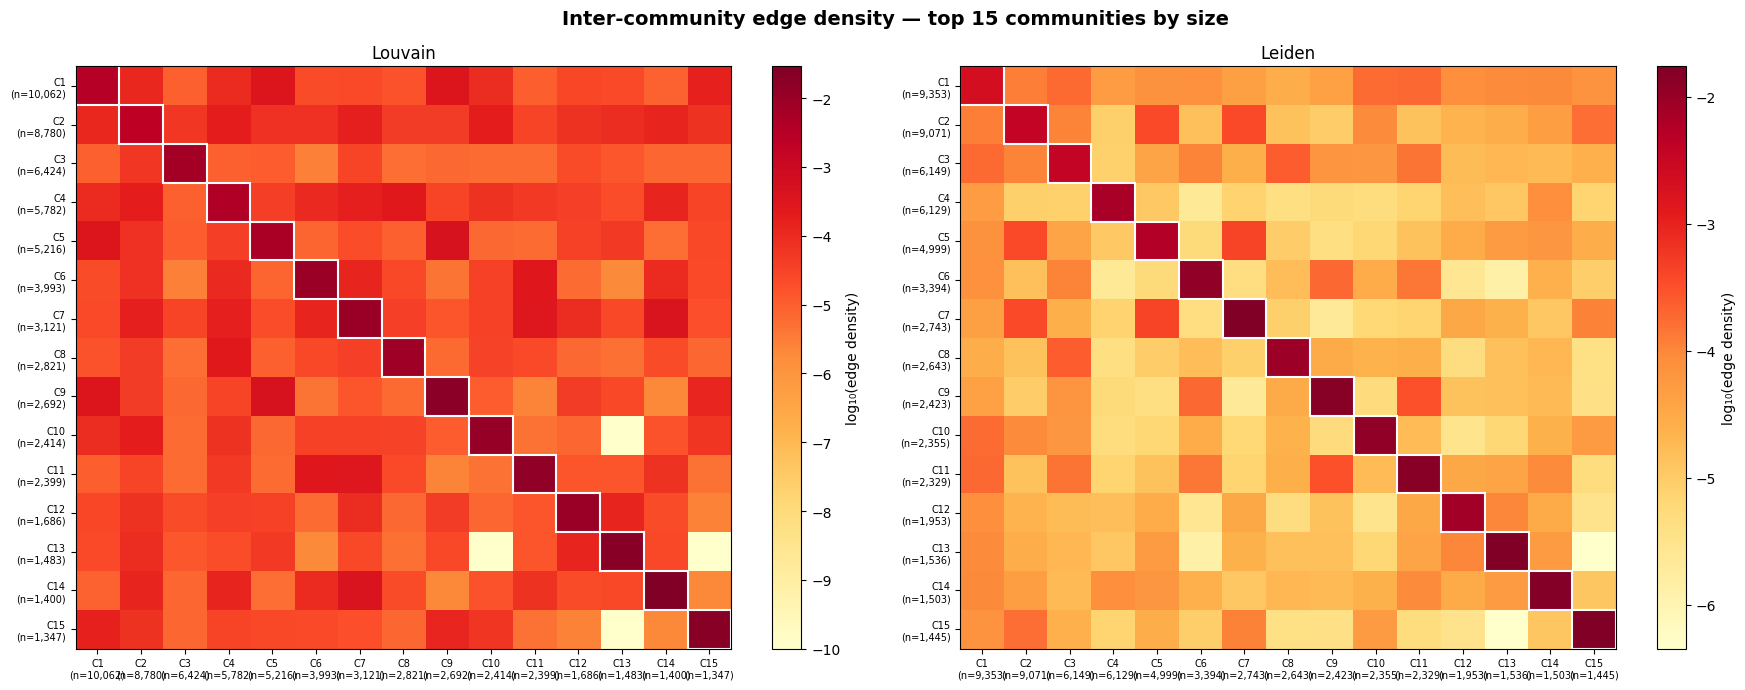

Saved: viz_heatmap.png


In [5]:
def inter_community_density_matrix(g, partition, top_k=15):
    """
    Compute edge density between top_k communities (by size).
    density[i,j] = edges(i,j) / (|C_i| * |C_j|)  for i!=j
    density[i,i] = intra-community density
    """
    membership = np.array(partition.membership)
    sizes = Counter(membership)
    top_communities = [c for c, _ in sizes.most_common(top_k)]
    idx_map = {c: i for i, c in enumerate(top_communities)}
    k = len(top_communities)

    edge_counts = np.zeros((k, k))
    for e in g.es:
        s, t = membership[e.source], membership[e.target]
        if s in idx_map and t in idx_map:
            i, j = idx_map[s], idx_map[t]
            edge_counts[i, j] += 1
            if i != j:
                edge_counts[j, i] += 1

    size_arr = np.array([sizes[c] for c in top_communities])
    density = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            if i == j:
                n = size_arr[i]
                denom = n * (n - 1) / 2
            else:
                denom = size_arr[i] * size_arr[j]
            density[i, j] = edge_counts[i, j] / denom if denom > 0 else 0

    labels = [f"C{i+1}\n(n={size_arr[i]:,})" for i in range(k)]
    return density, labels

TOP_K = 15
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f"Inter-community edge density — top {TOP_K} communities by size",
             fontsize=14, fontweight="bold")

for ax, (part, algo) in zip(axes, [(part_lou, "Louvain"), (part_lei, "Leiden")]):
    density, labels = inter_community_density_matrix(gcc, part, top_k=TOP_K)

    # Log-scale for better contrast (intra >> inter)
    log_density = np.log10(density + 1e-10)
    im = ax.imshow(log_density, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax, label="log₁₀(edge density)")

    ax.set_xticks(range(TOP_K))
    ax.set_yticks(range(TOP_K))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f"{algo}", fontsize=12)

    # Mark diagonal
    for i in range(TOP_K):
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1,
                                   fill=False, edgecolor="white", linewidth=1.5))

plt.tight_layout()
plt.savefig("viz_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_heatmap.png")

## 4. Plan B — Ego-network validation

Distribution of per-ego NMI and ARI scores, scatter plots, and algorithm comparison.

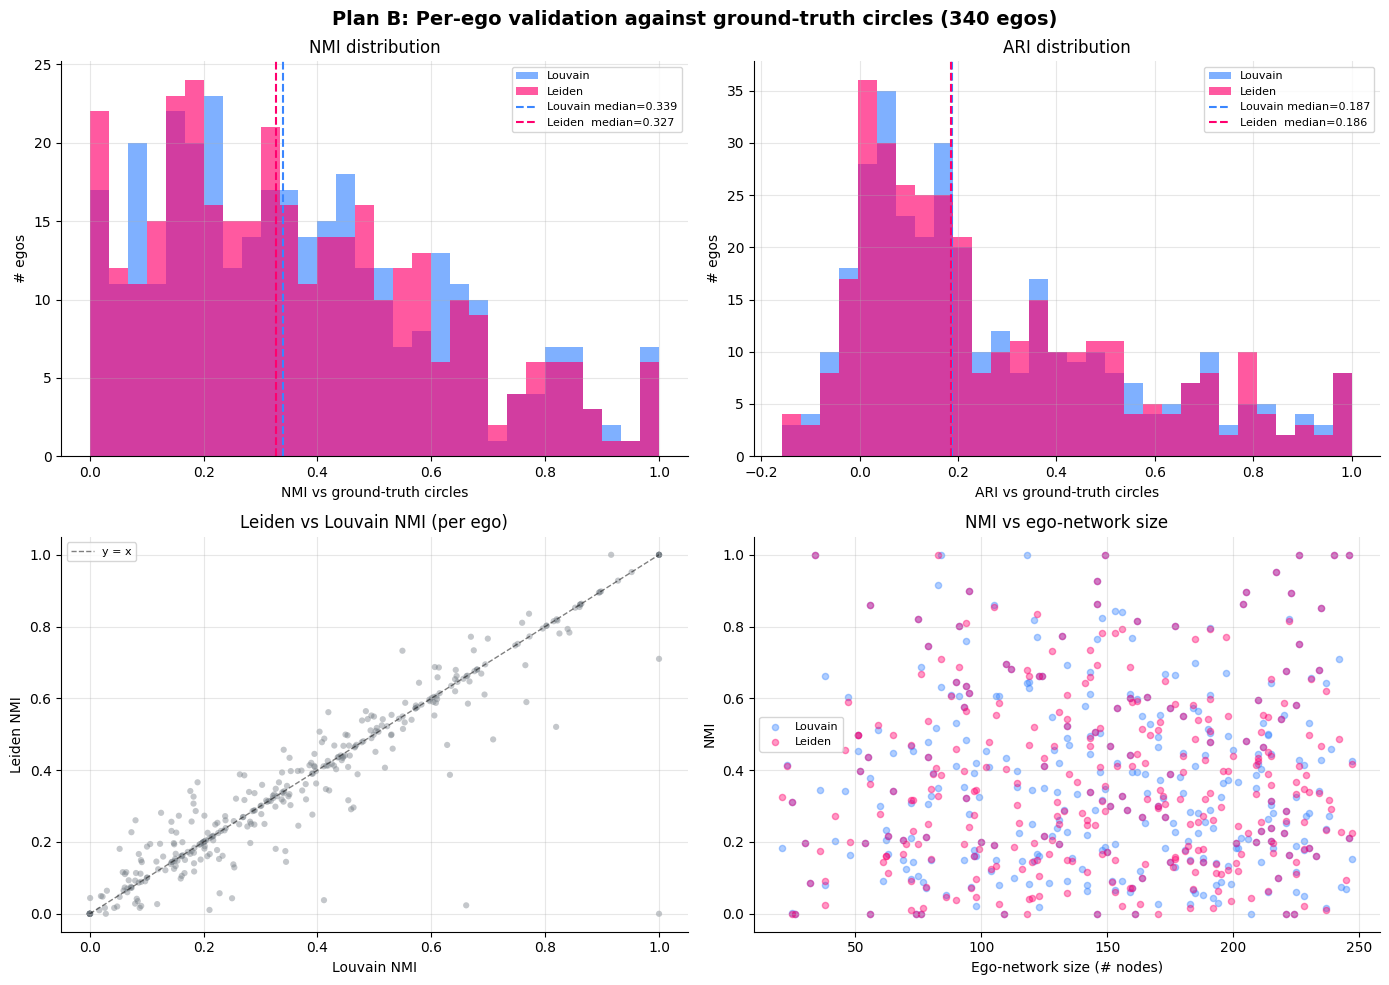

Saved: viz_planb.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Plan B: Per-ego validation against ground-truth circles (340 egos)",
             fontsize=14, fontweight="bold")

# --- 4a: NMI distributions ---
ax = axes[0, 0]
ax.hist(planb_df["lou_nmi"], bins=30, alpha=0.65, label="Louvain", color=COLORS["Louvain"])
ax.hist(planb_df["lei_nmi"], bins=30, alpha=0.65, label="Leiden",  color=COLORS["Leiden"])
ax.axvline(planb_df["lou_nmi"].median(), color=COLORS["Louvain"], linestyle="--", linewidth=1.5,
           label=f'Louvain median={planb_df["lou_nmi"].median():.3f}')
ax.axvline(planb_df["lei_nmi"].median(), color=COLORS["Leiden"],  linestyle="--", linewidth=1.5,
           label=f'Leiden  median={planb_df["lei_nmi"].median():.3f}')
ax.set_xlabel("NMI vs ground-truth circles")
ax.set_ylabel("# egos")
ax.set_title("NMI distribution")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# --- 4b: ARI distributions ---
ax = axes[0, 1]
ax.hist(planb_df["lou_ari"], bins=30, alpha=0.65, label="Louvain", color=COLORS["Louvain"])
ax.hist(planb_df["lei_ari"], bins=30, alpha=0.65, label="Leiden",  color=COLORS["Leiden"])
ax.axvline(planb_df["lou_ari"].median(), color=COLORS["Louvain"], linestyle="--", linewidth=1.5,
           label=f'Louvain median={planb_df["lou_ari"].median():.3f}')
ax.axvline(planb_df["lei_ari"].median(), color=COLORS["Leiden"],  linestyle="--", linewidth=1.5,
           label=f'Leiden  median={planb_df["lei_ari"].median():.3f}')
ax.set_xlabel("ARI vs ground-truth circles")
ax.set_ylabel("# egos")
ax.set_title("ARI distribution")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# --- 4c: Leiden NMI vs Louvain NMI scatter ---
ax = axes[1, 0]
ax.scatter(planb_df["lou_nmi"], planb_df["lei_nmi"],
           alpha=0.4, s=20, color="#6c757d", edgecolors="none")
lims = [0, max(planb_df[["lou_nmi", "lei_nmi"]].max())]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="y = x")
ax.set_xlabel("Louvain NMI")
ax.set_ylabel("Leiden NMI")
ax.set_title("Leiden vs Louvain NMI (per ego)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# --- 4d: NMI vs ego size ---
ax = axes[1, 1]
ax.scatter(planb_df["n_nodes"], planb_df["lou_nmi"],
           alpha=0.4, s=20, color=COLORS["Louvain"], label="Louvain")
ax.scatter(planb_df["n_nodes"], planb_df["lei_nmi"],
           alpha=0.4, s=20, color=COLORS["Leiden"],  label="Leiden")
ax.set_xlabel("Ego-network size (# nodes)")
ax.set_ylabel("NMI")
ax.set_title("NMI vs ego-network size")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_planb.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_planb.png")

## 5. Network layout — ego-network colored by community

We pick a medium-sized ego-network (100–400 nodes) and draw it with a Fruchterman-Reingold layout, coloring nodes by their detected community (Leiden). Nodes in the ground-truth circles are given distinct border colors.

In [9]:
# Pick a well-structured ego: medium size, ≥3 circles, good NMI
candidates = planb_df[
    (planb_df["n_nodes"].between(150, 350)) &
    (planb_df["n_circles"] >= 3) &
    (planb_df["lei_nmi"] > 0.3)
].sort_values("lei_nmi", ascending=False)

if len(candidates) == 0:
    candidates = planb_df[
        (planb_df["n_nodes"].between(100, 500)) &
        (planb_df["n_circles"] >= 2)
    ].sort_values("lei_nmi", ascending=False)

chosen_ego = str(int(candidates.iloc[0]["ego"]))
chosen_row = candidates.iloc[0]
print(f"Chosen ego: {chosen_ego}")
print(f"  nodes={int(chosen_row['n_nodes'])}, circles={int(chosen_row['n_circles'])}, "
      f"Leiden NMI={chosen_row['lei_nmi']:.3f}, Louvain NMI={chosen_row['lou_nmi']:.3f}")

Chosen ego: 14422788
  nodes=217, circles=3, Leiden NMI=0.952, Louvain NMI=0.952


In [10]:
# Load ego graph + ground-truth circles
edges_file   = EGO_DIR / f"{chosen_ego}.edges"
circles_file = EGO_DIR / f"{chosen_ego}.circles"

g_ego = ig.Graph.Read_Ncol(str(edges_file), directed=True, names=True).as_undirected(mode="collapse")
g_ego.simplify()

name_to_idx = {name: i for i, name in enumerate(g_ego.vs["name"])}

# Ground-truth circles
gt = np.full(g_ego.vcount(), -1, dtype=int)
circle_names = []
with open(circles_file) as f:
    for circle_idx, line in enumerate(f):
        parts = line.strip().split("\t")
        if len(parts) < 2:
            continue
        circle_names.append(parts[0])
        for m in parts[1:]:
            if m in name_to_idx and gt[name_to_idx[m]] == -1:
                gt[name_to_idx[m]] = circle_idx

# Run Leiden
part_ego_lei = la.find_partition(g_ego, la.ModularityVertexPartition, seed=42)
membership_lei = np.array(part_ego_lei.membership)

print(f"Ego graph: {g_ego.vcount()} nodes, {g_ego.ecount()} edges")
print(f"Leiden communities found: {len(part_ego_lei)}")
print(f"Ground-truth circles: {len(circle_names)}")
print(f"Labelled nodes: {(gt >= 0).sum()}")

Ego graph: 217 nodes, 1534 edges
Leiden communities found: 8
Ground-truth circles: 3
Labelled nodes: 27


C:\Users\suuser\AppData\Local\Temp\ipykernel_15944\1426786579.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_comm = plt.cm.get_cmap("tab20", n_comm)
C:\Users\suuser\AppData\Local\Temp\ipykernel_15944\1426786579.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_gt = plt.cm.get_cmap("Set1", n_circles)


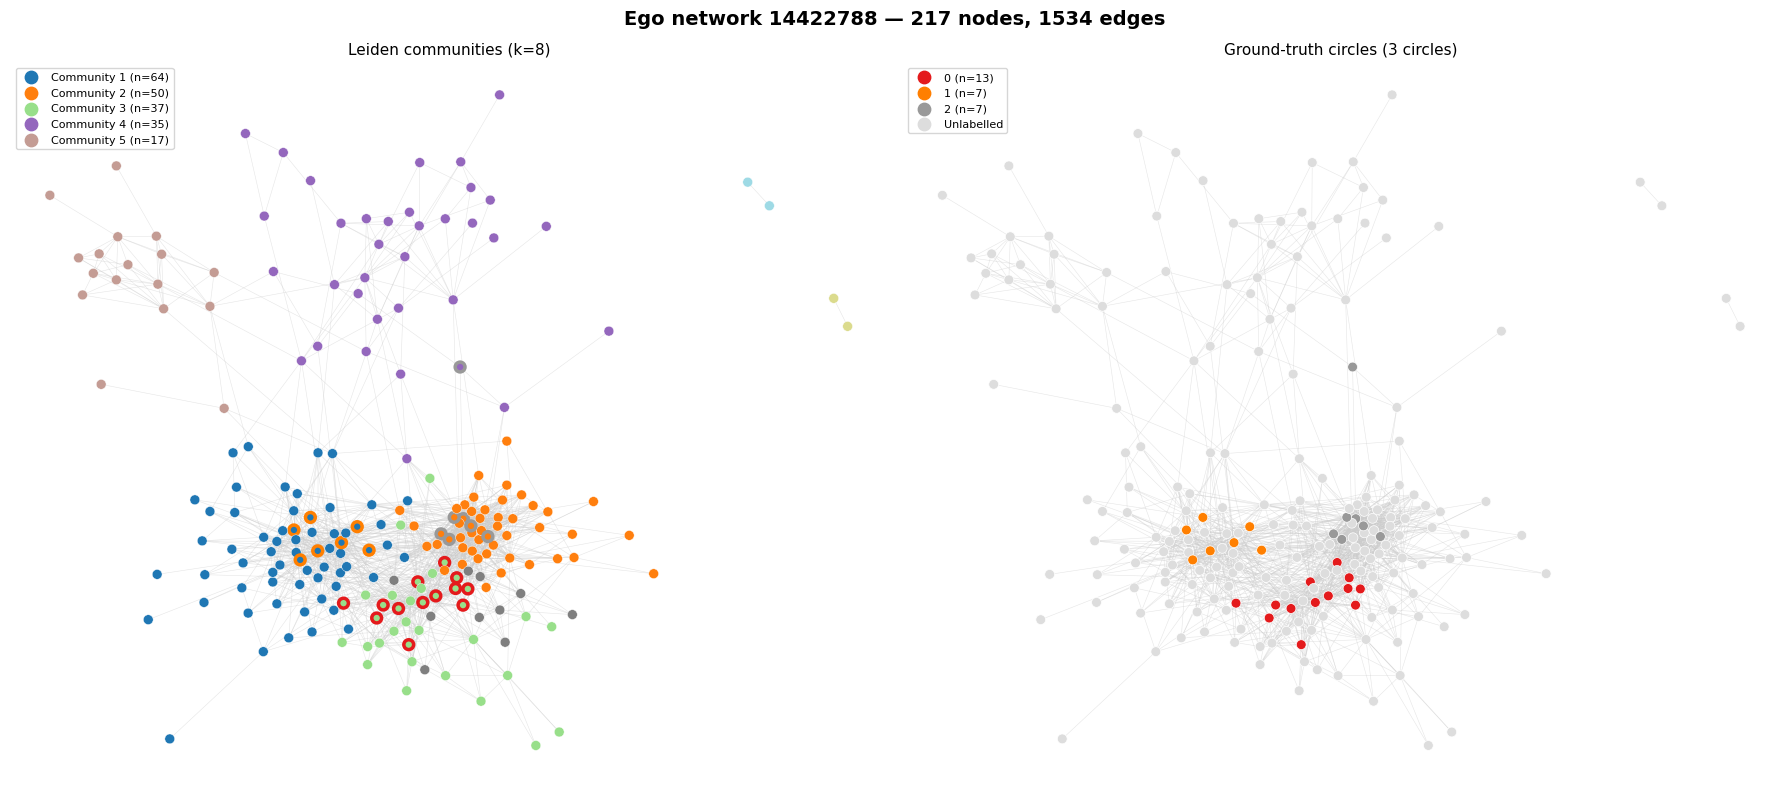

Saved: viz_ego_network.png


In [11]:
# Compute layout
layout = g_ego.layout("fr")   # Fruchterman-Reingold
coords = np.array(layout.coords)

# Color palette for detected communities
n_comm = len(part_ego_lei)
cmap_comm = plt.cm.get_cmap("tab20", n_comm)
node_colors = [cmap_comm(membership_lei[i]) for i in range(g_ego.vcount())]

# GT circle palette for borders
n_circles = int(gt.max()) + 1 if gt.max() >= 0 else 1
cmap_gt = plt.cm.get_cmap("Set1", n_circles)
border_colors = [cmap_gt(gt[i]) if gt[i] >= 0 else "white" for i in range(g_ego.vcount())]
border_widths  = [2.5 if gt[i] >= 0 else 0.3 for i in range(g_ego.vcount())]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(f"Ego network {chosen_ego} — {g_ego.vcount()} nodes, {g_ego.ecount()} edges",
             fontsize=14, fontweight="bold")

for ax_idx, (color_source, title) in enumerate([
    ("leiden",   f"Leiden communities (k={n_comm})"),
    ("gt",       f"Ground-truth circles ({n_circles} circles)"),
]):
    ax = axes[ax_idx]

    # Draw edges
    for e in g_ego.es:
        x0, y0 = coords[e.source]
        x1, y1 = coords[e.target]
        ax.plot([x0, x1], [y0, y1], color="#cccccc", linewidth=0.4, zorder=1, alpha=0.5)

    if color_source == "leiden":
        colors = node_colors
        borders = border_colors
        bwidths = border_widths
        # Legend for top-5 communities
        comm_sizes = Counter(membership_lei)
        for rank, (c, sz) in enumerate(comm_sizes.most_common(min(5, n_comm))):
            ax.scatter([], [], color=cmap_comm(c), s=80,
                       label=f"Community {rank+1} (n={sz})")
        ax.legend(fontsize=8, loc="upper left", framealpha=0.8)
    else:
        # Color by GT circle; unlabelled = gray
        colors = [cmap_gt(gt[i]) if gt[i] >= 0 else "#dddddd" for i in range(g_ego.vcount())]
        borders = ["white"] * g_ego.vcount()
        bwidths = [0.5] * g_ego.vcount()
        for ci in range(n_circles):
            sz = (gt == ci).sum()
            name = circle_names[ci] if ci < len(circle_names) else f"circle{ci}"
            ax.scatter([], [], color=cmap_gt(ci), s=80, label=f"{name} (n={sz})")
        ax.scatter([], [], color="#dddddd", s=80, label="Unlabelled")
        ax.legend(fontsize=8, loc="upper left", framealpha=0.8)

    ax.scatter(coords[:, 0], coords[:, 1],
               c=colors, edgecolors=borders, linewidths=bwidths,
               s=50, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.savefig("viz_ego_network.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: viz_ego_network.png")

In [ ]:
import plotly.graph_objects as go

# Küçük bir subgraph al (3D layout çok node'da çok yavaş)
# En büyük topluluğun ilk 500 node'unu al
comm_sizes_lei = Counter(membership_lei)
biggest_comm = comm_sizes_lei.most_common(1)[0][0]
nodes_in_comm = [i for i, m in enumerate(membership_lei) if m == biggest_comm][:500]

subg = g_ego.induced_subgraph(nodes_in_comm)
sub_membership = [membership_lei[i] for i in nodes_in_comm]

# 3D layout
layout_3d = subg.layout("fr3d")  # Fruchterman-Reingold 3D
coords_3d = np.array(layout_3d.coords)

# Edge traces
edge_x, edge_y, edge_z = [], [], []
for e in subg.es:
    x0, y0, z0 = coords_3d[e.source]
    x1, y1, z1 = coords_3d[e.target]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode="lines",
    line=dict(color="lightgray", width=0.5),
    hoverinfo="none",
)

# Node traces
node_trace = go.Scatter3d(
    x=coords_3d[:, 0],
    y=coords_3d[:, 1],
    z=coords_3d[:, 2],
    mode="markers",
    marker=dict(
        size=4,
        color=sub_membership,
        colorscale="Turbo",
        opacity=0.85,
        line=dict(width=0.5, color="white"),
    ),
    text=[f"Node {subg.vs[i]['name']}" for i in range(subg.vcount())],
    hoverinfo="text",
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title=f"3D Network — Ego {chosen_ego} (Leiden communities)",
    showlegend=False,
    scene=dict(
        xaxis=dict(showbackground=False),
        yaxis=dict(showbackground=False),
        zaxis=dict(showbackground=False),
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.write_html("viz_3d_network.html")
print("Saved: viz_3d_network.html")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 6. Summary table

Final consolidated table with all key results — ready to paste into the report.

In [12]:
from scipy.stats import wilcoxon

summary_rows = []

for algo in ["Louvain", "Leiden"]:
    sub = plana_df[plana_df["algo"] == algo]
    row = {
        "Algorithm": algo,
        "Q mean±std": f"{sub['modularity'].mean():.4f} ± {sub['modularity'].std():.4f}",
        "Q max": f"{sub['modularity'].max():.4f}",
        "k mean±std": f"{sub['n_communities'].mean():.1f} ± {sub['n_communities'].std():.1f}",
        "Runtime mean±std (s)": f"{sub['runtime_s'].mean():.2f} ± {sub['runtime_s'].std():.2f}",
    }
    # Plan B
    nmi_col = "lou_nmi" if algo == "Louvain" else "lei_nmi"
    ari_col = "lou_ari" if algo == "Louvain" else "lei_ari"
    row["Plan B NMI median"] = f"{planb_df[nmi_col].median():.4f}"
    row["Plan B ARI median"] = f"{planb_df[ari_col].median():.4f}"
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows).set_index("Algorithm")

# Wilcoxon tests
print("=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)
print(summary_table.T.to_string())

print("\n" + "=" * 60)
print("WILCOXON TESTS (Leiden − Louvain, 340 egos)")
print("=" * 60)
for metric_pair, name in [(("lou_nmi", "lei_nmi"), "NMI"),
                           (("lou_ari", "lei_ari"), "ARI"),
                           (("lou_Q",   "lei_Q"),   "Modularity")]:
    diff = planb_df[metric_pair[1]] - planb_df[metric_pair[0]]
    nonzero = diff[diff != 0]
    if len(nonzero) > 0:
        stat, p = wilcoxon(nonzero)
        winner = "Leiden" if diff.median() > 0 else "Louvain"
        print(f"{name:12s}: median diff = {diff.median():+.4f}   p = {p:.2e}   → {winner} wins")
    else:
        print(f"{name:12s}: no difference between algorithms")

summary_table.to_csv("viz_summary_table.csv")
print("\nSaved: viz_summary_table.csv")

FINAL SUMMARY TABLE
Algorithm                     Louvain           Leiden
Q mean±std            0.8035 ± 0.0051  0.8100 ± 0.0016
Q max                          0.8075           0.8112
k mean±std                 71.8 ± 2.1       75.5 ± 2.4
Runtime mean±std (s)      2.42 ± 0.29      1.51 ± 0.04
Plan B NMI median              0.3393           0.3274
Plan B ARI median              0.1874           0.1864

WILCOXON TESTS (Leiden − Louvain, 340 egos)
NMI         : median diff = +0.0000   p = 9.15e-01   → Louvain wins
ARI         : median diff = +0.0000   p = nan   → Louvain wins
Modularity  : median diff = +0.0012   p = 2.20e-21   → Leiden wins

Saved: viz_summary_table.csv
